In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
import glob
import os
from PIL import Image
from IPython.display import Image as IPImage


In [58]:
def euler1d_sd2_frames(J, N, P, print_status = False):
    """
    Generates snapshots of solution of 1D Euler Equations.
    
    Parameters:
        J : number of grid cells
        N : total number of outputs generated by CentPack
        P : number of processors
    """

    # Create output directories if they don't exist
    for d in ['rho_frames', 'u1_frames', 'p_frames']:
        os.makedirs(d, exist_ok=True)

    # Load mesh
    x = []
    for p in range(P):
        x_file = f'mesh_files/x_p{p:03d}'
        xp = np.loadtxt(x_file)
        x.append(xp)
    x = np.concatenate(x)

    # Loop over timesteps
    for n in range(N+1):
        rho   = []
        u1    = []
        press = []

        for p in range(P):
            rho_file = f'rho_files/rho_p{p:03d}_{n:03d}'
            u1_file  = f'u1_files/u1_p{p:03d}_{n:03d}'
            p_file   = f'p_files/p_p{p:03d}_{n:03d}'

            rho.append(np.loadtxt(rho_file))
            u1.append(np.loadtxt(u1_file))
            press.append(np.loadtxt(p_file))

        rho   = np.concatenate(rho)
        u1    = np.concatenate(u1)
        press = np.concatenate(press)

        # Plot density
        plt.figure()
        plt.plot(x, rho, '-.', linewidth=2)
        plt.axis([-1.0, 1.0, rho.min() - 0.05, rho.max() + 0.05])
        plt.savefig(f'rho_frames/rho_{n:03d}.png', dpi=72)
        plt.close()

        # Plot velocity
        plt.figure()
        plt.plot(x, u1, '-.', linewidth=2)
        plt.axis([-1.0, 1.0, u1.min() - 0.05, u1.max() + 0.05])
        plt.savefig(f'u1_frames/u1_{n:03d}.png', dpi=72)
        plt.close()

        # Plot pressure
        plt.figure()
        plt.plot(x, press, '-.', linewidth=2)
        plt.axis([-1.0, 1.0, press.min() - 0.05, press.max() + 0.05])
        plt.savefig(f'p_frames/p_{n:03d}.png', dpi=72)
        plt.close()

        if print_status:
            print(f'Saved frame {n}/{N}')

euler1d_sd2_frames(J=256, N=41, P=8)

In [54]:
def frames_to_gif(frame_dir, output_name, duration=100):
    frames = sorted(glob.glob(f'{frame_dir}/*.png'))
    images = [Image.open(f) for f in frames]
    images[0].save(
        output_name,
        save_all=True,
        append_images=images[1:],
        loop=0,
        duration=duration  # milliseconds per frame
    )

frames_to_gif('rho_frames', 'rho.gif')
frames_to_gif('u1_frames',  'u1.gif')
frames_to_gif('p_frames',   'p.gif')

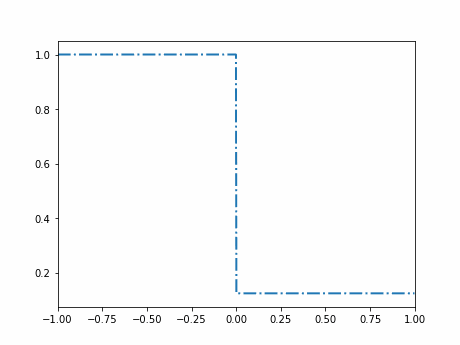

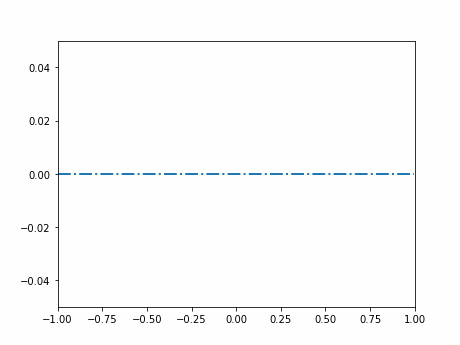

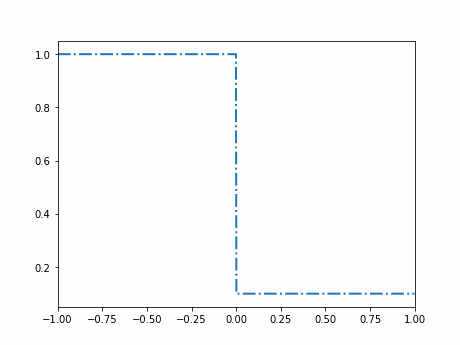

In [56]:
display(IPImage('rho.gif'))
display(IPImage('u1.gif'))
display(IPImage('p.gif'))